In [6]:
import MDAnalysis as mda
from MDAnalysis.transformations import wrap
import numpy as np
from MDAnalysis.topology.guessers import guess_atom_element
import warnings

# User parameters
dw_u2     = 0.1          # Debye–Waller parameter (Å^2)
wavelength = 0.976        # X-ray wavelength (Å)
alpha_i   = np.deg2rad(0.14)  # incident angle (rad)
q_max     = 2.2          # max |G| (Å^-1)

# Load pdb structure file
pdb_path = r"C:\Users\wax20\Downloads\giwaxs_sim\pdb\Figure_S5b.pdb"
univ   = mda.Universe(pdb_path)
transform = univ.trajectory.add_transformations(wrap(univ.atoms))
atoms   = univ.select_atoms("not name V")
pos     = atoms.positions.copy()   # (N_atoms,3)

# Suppress warnings: In the coarse grain model we parameterize the VDW force as element "V", but not calculated here 
warnings.filterwarnings("ignore", message="Element information is missing*")

# Identify elements
elems   = [guess_atom_element(a.name) for a in atoms]
C_mask  = np.array([e=='C' for e in elems])
S_mask  = np.array([e=='S' for e in elems])

# Reciprocal lattice basis from box vectors
Lx, Ly, Lz = univ.dimensions[:3]
a = np.array([Lx, 0, 0])
b = np.array([0, Ly, 0])
c = np.array([0, 0, Lz])
V_box = np.dot(a, np.cross(b, c))
a_star = 2*np.pi * np.cross(b, c) / V_box
b_star = 2*np.pi * np.cross(c, a) / V_box
c_star = 2*np.pi * np.cross(a, b) / V_box

# Atomic form factor coefficients
coeffs = {
    'C': {'a': np.array([2.31, 1.02, 1.5886, 0.865]),
          'b': np.array([20.8439,10.2075, 0.5687,51.6512]),
          'c': 0.2156},
    'S': {'a': np.array([6.9053,5.2034,1.4379,1.5863]),
          'b': np.array([1.4679,22.2151,0.2536,56.172 ]),
          'c': 0.8669}
}

# Precompute Lorentz–polarization constants
k0  = 2 * np.pi / wavelength
cos_ai, sin_ai = np.cos(alpha_i), np.sin(alpha_i)
k_i = np.array([k0*cos_ai, 0.0, -k0*sin_ai])

# Loop over (h,k,l) to compute S(G) 
# Determine h,k,l bounds
h_max = int(np.ceil(q_max / np.linalg.norm(a_star)))
k_max = int(np.ceil(q_max / np.linalg.norm(b_star)))
l_max = int(np.ceil(q_max / abs(c_star[2])))

# Compute S(G)
import itertools
from tqdm import tqdm
# Build iterator over all h,k,l combinations
h_vals = range(-h_max, h_max+1)
k_vals = range(-k_max, k_max+1)
l_vals = range(-l_max, l_max+1)
prod_iter = itertools.product(h_vals, k_vals, l_vals)
# Total count for progress bar
total = len(h_vals) * len(k_vals) * len(l_vals)
results = []
for h, k, l in tqdm(prod_iter, total=total, desc='Computing S(G)'):
    G = h*a_star + k*b_star + l*c_star
    qmag = np.linalg.norm(G)
    if qmag > q_max:
        continue
    # Atomic form factors
    u = (qmag/(4*np.pi))**2
    aC,bC,cC = coeffs['C']['a'], coeffs['C']['b'], coeffs['C']['c']
    fC = np.dot(aC, np.exp(-bC*u)) + cC
    aS,bS,cS = coeffs['S']['a'], coeffs['S']['b'], coeffs['S']['c']
    fS = np.dot(aS, np.exp(-bS*u)) + cS
    # Structure factor sum
    phases = np.exp(1j * pos.dot(G))
    Fq = fC*phases[C_mask].sum() + fS*phases[S_mask].sum()
    Sqq = np.abs(Fq)**2
    # Debye–Waller
    Sqq *= np.exp(-2*(dw_u2/3)*(qmag**2))
    # Lorentz–Polarization
    kf = G + k_i
    cos2th = np.clip(np.dot(kf,k_i)/k0**2, -1.0, 1.0)
    theta = np.arccos(cos2th)
    sin_theta = np.sin(theta)
    L = np.zeros_like(sin_theta)
    mask_zero = np.abs(sin_theta) > 1e-6
    L[mask_zero] = 1.0/sin_theta[mask_zero]
    P = (1 + cos2th**2)/2
    Sqq *= (L*P)
    Gr = np.sqrt(G[0]**2 + G[1]**2 + G[2]**2)
    Gz = abs(G[2])
    results.append((h, k, l, Gr, Gz, Sqq))

# Convert to structured array & sort by intensity
dtype = [('h', int), ('k', int), ('l', int), ('Gr', float), ('Gz', float), ('S', float)]
res_arr = np.array(results, dtype=dtype)

from collections import defaultdict

# Merge equivalent (Gr, Gz) reflections by summing intensities
intensity_dict = defaultdict(float)
hkl_dict = {}

for h, k, l, Gr, Gz, S in results:
    key = (round(abs(Gr), 6), round(abs(Gz), 6))  # Use absolute values for merging
    intensity_dict[key] += S
    if key not in hkl_dict:
        hkl_dict[key] = (h, k, abs(l), Gr, Gz)  # Save first (h,k,l), Gr, Gz as representative

# Build new merged result list
merged_results = []
for key, S_total in intensity_dict.items():
    h, k, l, Gr, Gz = hkl_dict[key]
    merged_results.append((h, k, l, Gr, Gz, S_total))

# Convert to structured array & sort by intensity
dtype = [('h',int), ('k',int), ('l',int), ('Gr',float), ('Gz',float), ('S',float)]
res_arr = np.array(merged_results, dtype=dtype)
res_sorted = np.sort(res_arr, order='S')[::-1]

# Filter out reflections of small Gr
res_filtered = res_sorted[res_sorted['Gr'] >= 0.13]

# Extract top sturcture factors, use # around 15 +-2 for top15, ~100 for top100
top100 = res_filtered[:15]

print("Top 15 Structure Factor (h,k,l): Gr, Gz, S")
for entry in top100:
    print(entry)

Computing S(G): 100%|█████████████████████████████████████████████████████████| 285483/285483 [06:34<00:00, 724.52it/s]


Top 15 Structure Factor (h,k,l): Gr, Gz, S
(0, -12, 4, 1.80501139, 0.45785801, 1.72558507e+11)
(0, 0, 4, 0.45785801, 0.45785801, 9.43521337e+10)
(0, -12, 1, 1.74972405, 0.1144645, 6.62936221e+10)
(0, -12, 3, 1.77942441, 0.34339351, 5.05354457e+10)
(0, -12, 2, 1.76092039, 0.22892901, 2.77144764e+10)
(0, 0, 8, 0.91571602, 0.91571602, 1.99880731e+10)
(0, -12, 5, 1.83738543, 0.57232252, 1.84387066e+10)
(-1, -12, 4, 1.80513334, 0.45785801, 6.79084245e+09)
(0, 0, 16, 1.83143205, 1.83143205, 4.64822722e+09)
(-40, -9, 8, 1.80491591, 0.91571602, 3.92094712e+09)
(-2, -12, 4, 1.80549916, 0.45785801, 3.86060881e+09)
(-40, -3, 12, 1.66783547, 1.37357404, 3.11114653e+09)
(-1, -12, 3, 1.77954812, 0.34339351, 2.91980746e+09)
(0, 0, 17, 1.94589655, 1.94589655, 2.6824797e+09)
(0, -12, 8, 1.9715395, 0.91571602, 2.38232574e+09)


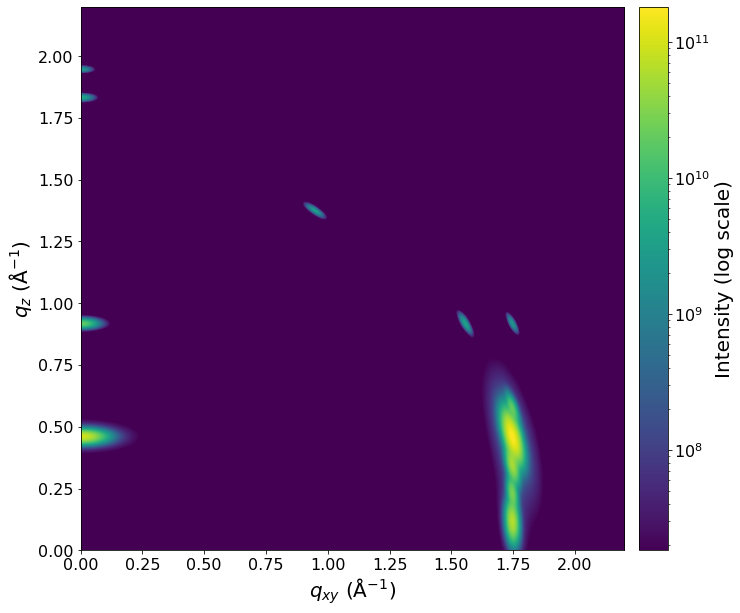

In [7]:
# Plot top15 or top100 simulated GIWAXS pattern
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm, ListedColormap
from matplotlib.patches import Ellipse
import matplotlib.transforms as mtrans

# Extract qr, qz, and intensities, note that Gr here is total q, qr=np.sqrt(qx**2+qy**2)
Gr_vals = top100['Gr']
Gz_vals = top100['Gz']
I_vals = top100['S']
qr=np.sqrt(Gr_vals**2-Gz_vals**2)

# Collect (h,k,l) tuples for annotation
hkl_vals = list(zip(top100['h'], top100['k'], top100['l']))

# Build a custom colormap and set its under-color
base_cmap   = plt.cm.get_cmap('viridis', 256)
colors      = base_cmap(np.linspace(0, 1, 256))
custom_cmap = ListedColormap(colors)
custom_cmap.set_under(colors[0])

plt.close('all')
# Prepare figure and axes
fig, ax = plt.subplots(figsize=(10,10))
# Use the under-color as axes background
ax.set_facecolor(colors[0])

# Create a high-resolution grid for the final image
pixels = 512 # Increase for higher resolution
q_plot_max = 2.2
final_image = np.zeros((pixels, pixels))
qr_vec = np.linspace(0, q_plot_max, pixels)
qz_vec = np.linspace(0, q_plot_max, pixels)
qr_grid, qz_grid = np.meshgrid(qr_vec, qz_vec)

# Peak width parameters 
sigma_r0 = 0.05
sigma_z0 = 0.015

# Loop through peaks to add their intensity to the final_image grid
# Iterate backwards to ensure the brightest peak is done last
for peak in top100[::-1]:
    # Extract values for the current peak
    x0 = np.sqrt(peak['Gr']**2 - peak['Gz']**2)
    y0 = peak['Gz']
    I = peak['S']
    # Angle for tangential elongation ("smile" shape)
    angle = np.degrees(np.arctan2(y0, x0)) + 90.0
    θ = np.deg2rad(angle)
    # Calculate peak size based on intensity
    fac = (np.sqrt(I / I_vals.max()))**0.5
    sigma_r_i = sigma_r0 * fac
    sigma_z_i = sigma_z0 * fac

    # Calculate peak shape directly on the main grid
    # 1. Translate grid to center the peak at the origin
    qr_prime = qr_grid - x0
    qz_prime = qz_grid - y0

    # 2. Rotate the translated grid to align with the peak's axes
    XR = qr_prime * np.cos(θ) + qz_prime * np.sin(θ)
    ZZ = -qr_prime * np.sin(θ) + qz_prime * np.cos(θ)

    # 3. Calculate the pseudo-Voigt function on this transformed grid
    mix_ratio = 0.05 # % Lorentzian
    G = I * np.exp(-0.5 * ((XR / sigma_r_i)**2 + (ZZ / sigma_z_i)**2))
    
    gamma_r = sigma_r_i * np.sqrt(2)
    gamma_z = sigma_z_i * np.sqrt(2)
    # Use a Lorentzian with a power of 2 for slightly faster decay than pure Lorentzian
    L = I / (1 + (XR / gamma_r)**2 + (ZZ / gamma_z)**2)**2 
    
    P = mix_ratio * L + (1 - mix_ratio) * G

    # 4. Add this peak's contribution to the final image
    final_image += P

# Plot the final grid as a single, smooth image
# Set the minimum of the log scale to a small fraction of the max intensity
# to avoid errors with zero values in the background.
Imax = final_image.max()
norm = LogNorm(vmin=Imax * 0.0001, vmax=Imax)

im = ax.imshow(final_image,
               origin='lower',
               extent=[0, q_plot_max, 0, q_plot_max],
               cmap=custom_cmap,
               norm=norm,
               interpolation='antialiased' # Helps with smoothing
              )

# Function to draw the (h,k,l) labels
'''
def adjust_labels(ax, xs, ys, labels):
    for x, y, label in zip(xs, ys, labels):
        ax.annotate(
            f"{label}",
            xy=(x, y),
            xytext=(10, 10),            # offset in points
            textcoords='offset points',
            fontsize=8,
            color='white',           # white text for contrast
            ha='left',
            va='bottom'
        )

adjust_labels(ax, qr, Gz_vals, hkl_vals)

'''


# Extend axes to start at zero
ax.set_xlim(0, q_max)
ax.set_ylim(0, q_max)
ax.set_aspect('equal', 'box')

# Make the colorbar the same length as the figure
pos = ax.get_position()
# Define the position and size for the colorbar axes
# [left, bottom, width, height]
cbar_ax = fig.add_axes([pos.x0 + pos.width + 0.02, pos.y0, 0.04, pos.height])

# Add a colorbar
cb = fig.colorbar(im, cax=cbar_ax)
cb.set_label('Intensity (log scale)', fontsize=20)
cb.ax.tick_params(labelsize=16)

# Add axis labels
ax.set_xlabel(r'$q_{xy}$ (Å$^{-1}$)',fontsize=20)
ax.set_ylabel(r'$q_z$ (Å$^{-1}$)',fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)


plt.show()